# Phase 1: Data Loading, EDA, and Corpus Conditioning
This phase handles ingestion of the arXiv data snapshot, executes thorough exploratory analysis to detect outliers and temporal biases, and isolates a representative, stratified sample tailored for our recency-aware RAG system.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from collections import Counter
import json
import re
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama

import ollama

from tqdm.auto import tqdm

# Paths and Ingestion Configurations
DATA_PATH = Path("../data/raw/arxiv-metadata-oai-snapshot.json")
TARGET_CATEGORIES = {"cs.AI", "cs.CL", "cs.LG", "stat.ML"}

## 1. Data Loading

In [2]:
def load_data(data_path, target_categories):
    """Loads and filters the jsonl file based on targeted category regex matches."""
    cat_regex = re.compile("|".join([re.escape(cat) for cat in target_categories]))
    filtered_data = []
    
    with open(data_path, "r", encoding="utf-8") as f:
        for line in f:
            if cat_regex.search(line):
                item = json.loads(line.strip())
                categories = set(item.get("categories", "").split())
                if categories.intersection(target_categories):
                    filtered_data.append(item)

    return pd.DataFrame(filtered_data) 

In [3]:
raw = load_data(data_path=DATA_PATH, target_categories=TARGET_CATEGORIES)
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433013 entries, 0 to 433012
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              433013 non-null  object
 1   submitter       432829 non-null  object
 2   authors         433013 non-null  object
 3   title           433013 non-null  object
 4   comments        249203 non-null  object
 5   journal-ref     41379 non-null   object
 6   doi             51975 non-null   object
 7   report-no       5197 non-null    object
 8   categories      433013 non-null  object
 9   license         430011 non-null  object
 10  abstract        433013 non-null  object
 11  versions        433013 non-null  object
 12  update_date     433013 non-null  object
 13  authors_parsed  433013 non-null  object
dtypes: object(14)
memory usage: 46.3+ MB


## 2. Exploratory Data Analysis (EDA)
Before building our retrieval index, we must analyze the structural integrity, text lengths, temporal distributions, and revision profiles of our ingested documents.

### 2.1. Integrity Check & Category Density
We verify the uniqueness of document identifiers and analyze the density of our target domains across cross-listed papers.

In [4]:
# Verify primary key integrity
duplicate_ids = raw["id"].duplicated().sum()
print(f"Total Duplicated IDs found: {duplicate_ids}")

# Calculate individual category representation across documents
ctg_counter = Counter()
raw["categories"].str.split().apply(ctg_counter.update)

counts_series = (
    pd.Series({k: v for k, v in ctg_counter.items() if k in TARGET_CATEGORIES})
    .sort_values(ascending=False)
)
print("\nCategory Representation Share (%):")
print(round(100 * counts_series / len(raw), 2))

Total Duplicated IDs found: 0

Category Representation Share (%):
cs.LG      61.17
cs.AI      40.69
cs.CL      25.03
stat.ML    17.85
dtype: float64


### 2.2. Text Length Diagnostics (Token & Word Counts)
Evaluating the distribution of abstract and title lengths allows us to detect anomalies (such as empty strings or system notifications) and determine chunking boundaries.

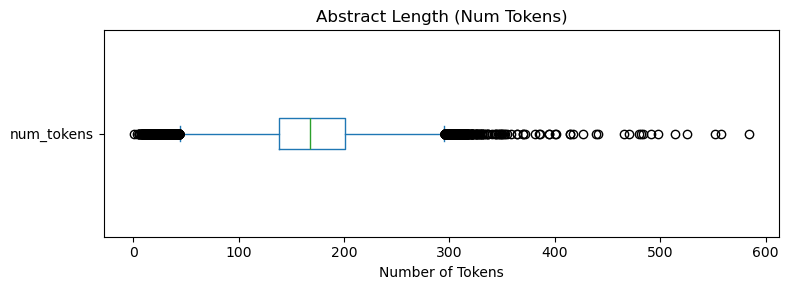

Abstract Lengths -> Min: 1 | Mean: 169.94 (Std: 47.48) | Max: 584

Title Length Distribution Metrics:
count    433013.00
mean          9.62
std           3.21
min           1.00
25%           7.00
50%           9.00
75%          12.00
max          36.00
Name: title_length, dtype: float64


In [5]:
# Compute text lengths based on space-separated tokens
raw["num_tokens"] = raw["abstract"].str.split().str.len()
raw["title_length"] = raw["title"].str.split().str.len()

# Visualize Abstract Outliers
raw["num_tokens"].plot.box(vert=False, figsize=(8, 3)).set(
    title="Abstract Length (Num Tokens)",
    xlabel="Number of Tokens"
)
plt.tight_layout()
plt.show()

mean_tokens = raw["num_tokens"].mean()
std_tokens = raw["num_tokens"].std()
print(f"Abstract Lengths -> Min: {raw['num_tokens'].min()} | "
      f"Mean: {mean_tokens:.2f} (Std: {std_tokens:.2f}) | "
      f"Max: {raw['num_tokens'].max()}")

# Inspect Title Length Summary
print("\nTitle Length Distribution Metrics:")
print(raw["title_length"].describe().round(2))

### 2.3 Temporal Dynamics & Version Evolution
Understanding document distribution over time and track submission histories is imperative for mapping metadata layers for our recency-aware retrieval strategy.

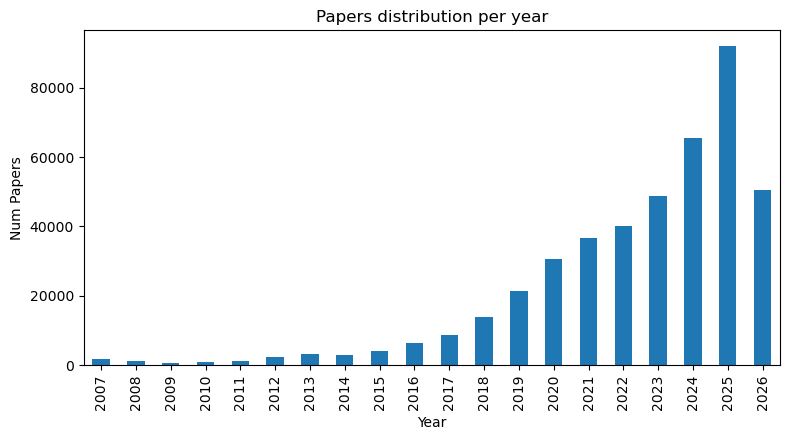

Submission Version Profile Statistics:
count    433013.00
mean          1.65
std           1.02
min           1.00
25%           1.00
50%           1.00
75%           2.00
max          35.00
Name: num_versions, dtype: float64
Percentage of documents with multiple revisions (v2+): 40.67%


In [6]:
# Temporal distribution tracking
raw["year"] = pd.to_datetime(raw["update_date"]).dt.year

raw["year"].value_counts().sort_index().plot.bar(figsize=(8, 4.5)).set(
    title="Papers distribution per year", xlabel="Year", ylabel="Num Papers"
)
plt.tight_layout()
plt.show()

# Version tracking profile
raw["num_versions"] = raw["versions"].apply(len)
print("Submission Version Profile Statistics:")
print(raw["num_versions"].describe().round(2))

revised_pct = round(100 * len(raw[raw["num_versions"] >= 2]) / len(raw), 2)
print(f"Percentage of documents with multiple revisions (v2+): {revised_pct}%")

### 2.4 Document Credibility (Publication Signal)
We map preprints into quality categories based on the presence of peer-review registration tokens (`doi`/`journal-ref`).

In [7]:
def compute_publication_signal(row):
    if pd.notna(row["doi"]) or pd.notna(row["journal-ref"]):
        return True
    return False

raw["is_published"] = raw.apply(compute_publication_signal, axis=1)

print("Source Publication Rate (%):")
print(raw["is_published"].value_counts(normalize=True).mul(100).round(2))

Source Publication Rate (%):
is_published
False    84.39
True     15.61
Name: proportion, dtype: float64


## 3. RAG Corpus Conditioning & Stratified Sampling

### 3.1. Temporal Scope Selection (2020-2026)
The corpus was restricted to papers published between 2020 and 2026 to better reflect the fast-moving nature of modern ML and NLP research. Because the project prioritizes recency-aware retrieval, including significantly older papers would increase the likelihood of surfacing semantically relevant but practically outdated work. Limiting the time window reduces retrieval noise, lowers indexing cost, and creates a more realistic research-assistant setting focused on contemporary methods, benchmarks, and architectures while still preserving several years of historical context.

### 3.2. RAG Text Processing Strategy Note
Considering the RAG system, traditional text preprocessing risks diluting semantic nunace and corrupting domain-specific information (e.g. mathematical formulas, scientific symbols, and metrics) that provide vital signal to vector embedding models and downstream LLMs. Furthermore, conducting data quality control via token length thresholds allows us to cleanly purge noise without modifying the underlying texts.

While legitimate academic abstracts typically conform to a standard 150-200 words, short abstracts almost exclusively represent placeholder text, non-peer-reviewed drafts, or procedural notifications such as "this paper has been retracted" or "an updated version will be uploaded later". Slicing out these low-token outliers provides an elegant, non-destructive method for filtering junk data while fully preserving the linguistic integrity of the knowledge base.

### 3.3. Corpus Downsampling
Although the filtered corpus may still contain several hundred thousand papers, the final retrieval corpus is further subsampled to 50,000 documents to keep embedding generation, vector indexing, and iterative experimentation computationally practical. This scale was large enough to preserve topical diversity and realistic retrieval difficulty while significantly reducing indexing time, storage requirements, and API costs during development and evaluation.

In [8]:
def sample_data(df, year_range=None, n=50000):
    """Filters data for constraints, handles chronological deduplication, and returns a stratified sample."""
    rag_df = df.copy()
    
    # Standardize necessary columns dynamically if not run sequentially
    if "num_tokens" not in rag_df.columns:
        rag_df["num_tokens"] = rag_df["abstract"].str.split().str.len()
    if "year" not in rag_df.columns:
        rag_df["year"] = pd.to_datetime(rag_df["update_date"]).dt.year
    if "is_published" not in rag_df.columns:
        rag_df["is_published"] = rag_df.apply(compute_publication_signal, axis=1)
    
    # Calculate Statistical Token Thresholds
    mean_tokens = rag_df["num_tokens"].mean()
    std_tokens = rag_df["num_tokens"].std()
    lower_limit = max(30, mean_tokens - 2.5 * std_tokens)
    upper_limit = mean_tokens + 2.5 * std_tokens
    print(f"Filtering abstracts outside of token range: [{lower_limit:.1f}, {upper_limit:.1f}]")

    # Structural Integrity Masks
    token_mask = rag_df["num_tokens"].between(lower_limit, upper_limit)
    text_exist_mask = rag_df["abstract"].notna() & (rag_df["abstract"].str.strip() != "")
    id_exist_mask = rag_df["id"].notna()
    mask = id_exist_mask & text_exist_mask & token_mask
    
    rag_df = rag_df[mask].sort_values(by="update_date", ascending=True)

    # Chronological Deduplication (Ensures we keep the absolute newest version information)
    rag_df = rag_df.drop_duplicates(subset=["title"], keep="last")

    # Apply Temporal Window Filters
    if year_range:
        rag_df = rag_df[rag_df["year"].between(year_range[0], year_range[1])]

    # Execution of Stratified Sampling per Year Block
    sampling_fraction = n / len(rag_df)

    rag_df = (
        rag_df.groupby("year", group_keys=False)
        .sample(frac=sampling_fraction, random_state=42)
    ).sample(n=n, random_state=42)

    rag_df["id"] = "arxiv." + rag_df["id"]

    keep_cols = ["id", "year", "is_published", "title", "abstract"]
    return rag_df[keep_cols]

# Build conditioned production subset
rag_df = sample_data(raw, year_range=(2020, 2026), n=50000)
print(f"Corpus conditioned. Final Shape for LangChain Pipeline: {rag_df.shape}")

Filtering abstracts outside of token range: [51.3, 288.6]
Corpus conditioned. Final Shape for LangChain Pipeline: (50000, 5)


In [9]:
rag_df.head(10)

,id,year,is_published,title,abstract
367453,arxiv.2509.10541,2025,False,"Situation Model of the Transport, Transport Em...",Air pollution in cities and the possibilities ...
177071,arxiv.2209.09316,2022,False,Activity report analysis with automatic single...,In the era of loT (Internet of Things) we ar...
82491,arxiv.2003.06495,2020,False,Human Preference-Based Learning for High-dimen...,Optimizing lower-body exoskeleton walking ga...
162467,arxiv.2205.03092,2022,False,Federated Learning with Noisy User Feedback,Machine Learning (ML) systems are getting in...
341438,arxiv.2505.19188,2025,False,Chordless Structure: A Pathway to Simple and E...,Researchers have proposed various methods of i...
335999,arxiv.2505.03829,2025,False,VideoLLM Benchmarks and Evaluation: A Survey,The rapid development of Large Language Mode...
188527,arxiv.2212.06089,2022,False,Hand-breathe: Non-Contact Monitoring of Breath...,"In post-covid19 world, radio frequency (RF)-..."
430101,arxiv.2605.06261,2026,False,Inference-Time Refinement Closes the Synthetic...,Diffusion-based generators set the current sta...
83004,arxiv.2003.09772,2020,False,Invariant Rationalization,Selective rationalization improves neural ne...
261286,arxiv.2404.14271,2025,True,Sparse Explanations of Neural Networks Using P...,Explainability is a key component in many appl...


In [10]:
import gc
# Unlink the large raw variables from the global scope
del raw
# Force the Python Garbage Collector to reclaim the newly freed blocks
gc.collect()

2858

# Phase 2: Vector Indexing and Knowledge Base Construction
This phase transforms our `rag_df` DataFrame into a production-ready high-performance semantic search index. We convert our structured data into LangChain `Document` structures, inject critical temporal and quality metadata, generate dense embeddings, and compile a localized vector index with FAISS for fast lookups.

In [2]:
load_dotenv()

if "OPENAI_API_KEY" not in os.environ:
    raise ValueError("OPENAI_API_KEY environment variable is missing")

INDEX_DIR = Path("../indexes")
INDEX_DIR.mkdir(parents=True, exist_ok=True)
FAISS_INDEX_NAME = "arxiv_index"

## 4. Document Transformation & Metadata Hydration
This section prepares our tabular data for vector indexing. We transform our DataFrame into LangChain document abstractions while adding a metadata hydration layer.

*Note:* **Metadata hydration (enrichment)** in Retrieval-Augmented Generation (RAG) is the process of enriching text chunks with contextual attributes before storing them in a vector database. This allows systems to perform targeted pre-filtering and provide reliable, traceable citations in AI responses.

Each hydrated element is explicitly selected to serve a specific architectural function during the retrieval and generation phases:

- `id`: Acts as the immutable primary key. It allows the system to trace any retrieved chunk back to its source file in the original dataset and prevents duplicate document ingestion if the index is updated.
- `title`: By isolating the title as clean metadata, the downstream LLM can instantly generate accurate, human-readable citations (e.g., "According to [Title]...") without needing to guess or parse it out of the raw abstract body text.
- `year`: Serves a dual purpose. It allows for strict boolean pre-filtering (e.g., isolating papers published within a specific timeline) and acts as a dynamic numerical variable to calculate the recency multiplier in our composite scorer.
- `is_published`: When convertedd to qualitative scalar, it supplies the numerical input required for our composite score formula to mathematically favor peer-reviewed literature.

In [ ]:
# Initialize our primary LangChain Document collection
documents = []

for idx, row in rag_df.iterrows():
    doc = Document(
        page_content=f"# Title: {row['title']}\n# Abstract:\n{row['abstract']}",
        metadata={
            "id": row["id"],
            "title": row["title"],
            "year": int(row["year"]),
            "is_published": int(row["is_published"])
        }
    )
    documents.append(doc)

print(f"✓ Successfully processed {len(documents)} documents.")
print(f"Verification - Sample Content:\n{documents[0].page_content[:150]}...")
print(f"Verification - Sample Metadata:\n{documents[0].metadata}")

## 5. Semantic Embedding & FAISS Index
This section vectorizes our corpus and constructs the local search graph. We pass our 50,000 hydrated documents to OpenAI's dense encoder, mapping the combined titles and abstracts into a 1536-dimensional semantic vector space. These arrays are ingested into a FAISS (Facebook AI Similarity Search) index alongside their metadata payloads and serialized directly to disk, creating an immutable knowledge base for retrieval.

We use `text-embedding-3-small` to create embeddings for its balance on low cost, high semantic accuracy on global bechmarks, and lower memory usage compared to other options.

In [3]:
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    chunk_size=1000
)

In [ ]:
print(f"Adding {len(documents)} documents into FAISS vector space...")

vectorstore = FAISS.from_documents(
    documents=documents,
    embedding=embedding_model
)

vectorstore.save_local(
    folder_path=str(INDEX_DIR),
    index_name=FAISS_INDEX_NAME
)

print(f"✓ Index cached at: {INDEX_DIR / FAISS_INDEX_NAME}")

# Phase 3: Evaluation Dataset Construction (Synthetic QA Generation)
To rigorously benchmark our RAG pipeline, we isolate a golden evaluation dataset of 400 documents from our filtered corpus using a year-stratified loop to match our index density. This 400-document sample satisfies the statistical requirements for a 5% margin of error at a 95% confidence level, while remaining highly optimized for local inference execution budgets.

We use a local LLM with Ollama to synthetically generate realistic, domain-specific user queries based on the target abstracts. This non-destructive process preserves 100% data overlap with our index, creating a ground-truth dataset (`query`, `ground_truth_context`, `ground_truth_id`) to evaluate our downstream retrieval and generation accuracy.

In [4]:
# Load previously saved eval_df
rag_df = pd.read_parquet("../data/processed/arxiv_rag_corpus.parquet")
rag_df.head()

,id,year,is_published,title,abstract
0,arxiv.2509.10541,2025,False,"Situation Model of the Transport, Transport Em...",Air pollution in cities and the possibilities ...
1,arxiv.2209.09316,2022,False,Activity report analysis with automatic single...,In the era of loT (Internet of Things) we ar...
2,arxiv.2003.06495,2020,False,Human Preference-Based Learning for High-dimen...,Optimizing lower-body exoskeleton walking ga...
3,arxiv.2205.03092,2022,False,Federated Learning with Noisy User Feedback,Machine Learning (ML) systems are getting in...
4,arxiv.2505.19188,2025,False,Chordless Structure: A Pathway to Simple and E...,Researchers have proposed various methods of i...


In [5]:
vectorstore = FAISS.load_local(
    folder_path=str(INDEX_DIR),
    embeddings=embedding_model,
    index_name=FAISS_INDEX_NAME,
    allow_dangerous_deserialization=True,
)

In [6]:
EVAL_N = 400

latest_year = rag_df["year"].max()
min_eval_year = latest_year - 1

eval_candidate_df = rag_df[
    (rag_df["year"] >= min_eval_year) &
    (rag_df["year"] <= latest_year) &
    (rag_df["is_published"])
].copy()

eval_source_df = (
    eval_candidate_df
    .sample(n=min(EVAL_N, len(eval_candidate_df)), random_state=42)
    .reset_index(drop=True)
)

print(
    f"Isolated {len(eval_source_df)} published papers from {min_eval_year}-{latest_year} "
    f"for recency-aware synthetic query generation."
)

print(f"Candidate pool size: {len(eval_candidate_df)}")

Isolated 400 published papers from 2025-2026 for recency-aware synthetic query generation.
Candidate pool size: 2215


### Synthetic Queries Generation
The evaluation benchmark was intentionally constructed as a **recency-aware retrieval setting**. For this, we generate synthetic researcher-style queries from published papers sampled from the most recent two years of the corpus. This design reflects the intended production use case: researchers searching for current and credible literature from a broader multi-year research archive.

In [7]:
def summarize_abstract(title, abstract, model="gemma3:4b"):
    system_prompt = (
        "You are summarizing research papers for retrieval evaluation.\n\n"
        "Given a paper title and abstract, write a neutral 2-3 sentence summary of the paper's main research problem, "
        "method family, and contribution.\n\n"
        "Rules:\n"
        "1. Do not copy long phrases from the abstract.\n"
        "2. Do not mention 'this paper' or 'the authors'.\n"
        "3. Avoid excessive detail, rare implementation names, or exact title wording.\n"
        "4. Return only the summary."
    )

    user_content = f"Title: {title}\n\nAbstract:\n{abstract}\n\nSummary:"

    try:
        response = ollama.chat(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_content}
            ],
            options={"temperature": 0.2}
        )
        return response.message.content.strip()
    except Exception as e:
        return f"ERROR_SUMMARY_FAILED: {str(e)}"

In [8]:
def generate_synthetic_query(title, summary, categories=None, model="gemma3:4b"):
    system_prompt = (
        "You are creating synthetic evaluation queries for a research-paper retrieval system.\n\n"
        "Given a paper title, short summary, and categories, generate ONE realistic researcher query that could retrieve "
        "a small group of related papers, including the seed paper.\n\n"
        "The query must:\n"
        "1. Be a natural research question or technical search request, not a paper title or keyword dump.\n"
        "2. Express an information need about methods, comparisons, limitations, datasets, applications, or evaluation.\n"
        "3. Be specific enough to retrieve related work, but not so specific that only one exact paper can match.\n"
        "4. Avoid copying the paper title or rare phrases from the summary.\n"
        "5. Avoid exact method names or acronyms unless they are widely used field terms.\n"
        "6. Avoid self-referential phrases like 'this paper', 'the authors', or 'the proposed method'.\n"
        "7. Be 12-25 words long.\n"
        "8. Return only the query string."
    )

    user_content = (
        f"Title: {title}\n"
        f"Categories: {categories}\n\n"
        f"Summary:\n{summary}\n\n"
        "Query:"
    )

    try:
        response = ollama.chat(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_content}
            ],
            options={"temperature": 0.4}
        )
        return response.message.content.strip()
    except Exception as e:
        return f"ERROR_GENERATION_FAILED: {str(e)}"

In [9]:
def build_relevance_group_from_seed(
    seed_text,
    seed_id,
    vectorstore,
    group_k=10,
):
    """
    Finds a local semantic neighborhood around the seed paper.
    This becomes the relevance group for the generated query.

    Includes the seed paper plus its nearest neighbors from the full corpus.
    """
    docs = vectorstore.similarity_search(seed_text, k=group_k)

    relevant_ids = []

    for doc in docs:
        doc_id = doc.metadata.get("id") or doc.metadata.get("doc_id")
        if doc_id is not None:
            relevant_ids.append(doc_id)

    if seed_id not in relevant_ids:
        relevant_ids.insert(0, seed_id)

    # Deduplicate while preserving order
    relevant_ids = list(dict.fromkeys(relevant_ids))

    return relevant_ids

In [10]:
eval_records = []

model = "gemma3:4b"
GROUP_K = 10

print(f"Starting synthetic generation via Ollama ({model})...")

for idx, row in tqdm(
    eval_source_df.iterrows(),
    total=len(eval_source_df),
    desc="Generating eval queries"
):
    title = row["title"]
    abstract = row["abstract"]
    categories = row.get("categories", None)
    seed_id = row["id"]

    summary = summarize_abstract(
        title=title,
        abstract=abstract,
        model=model
    )

    if "ERROR_SUMMARY_FAILED" in summary:
        continue

    synthetic_query = generate_synthetic_query(
        title=title,
        summary=summary,
        categories=categories,
        model=model
    )

    if "ERROR_GENERATION_FAILED" in synthetic_query:
        continue

    seed_text = f"Title: {title}\n\nSummary: {summary}"

    relevant_group_ids = build_relevance_group_from_seed(
        seed_text=seed_text,
        seed_id=seed_id,
        vectorstore=vectorstore,
        group_k=GROUP_K
    )

    eval_records.append({
        "query": synthetic_query,
        "seed_paper_id": seed_id,
        "relevant_paper_ids": relevant_group_ids,
        "seed_title": title,
        "seed_summary": summary,
        "seed_abstract": abstract,
        "year": row["year"],
        "is_published": row["is_published"],
        "categories": categories,
    })

eval_df = pd.DataFrame(eval_records)

print(f"Evaluation dataset successfully built. Shape: {eval_df.shape}")
eval_df.head()

Starting synthetic generation via Ollama (gemma3:4b)...


Generating eval queries:   0%|          | 0/400 [00:00<?, ?it/s]

Evaluation dataset successfully built. Shape: (400, 9)


,query,seed_paper_id,relevant_paper_ids,seed_title,seed_summary,seed_abstract,year,is_published,categories
0,What are the most effective federated learning...,arxiv.2502.17226,"[arxiv.2502.17226, arxiv.2103.11870, arxiv.191...",Electrical Load Forecasting over Multihop Smar...,The research investigates improving electric l...,Electric load forecasting is essential for pow...,2025,True,None
1,How can visual representations of vector graph...,arxiv.2404.06479,"[arxiv.2404.06479, arxiv.2604.07518, arxiv.250...",Visually Descriptive Language Model for Vector...,Research investigates the challenge of large m...,"Despite significant advancements, large multim...",2025,True,None
2,What are the key terrain features and their re...,arxiv.2309.15400,"[arxiv.2309.15400, arxiv.2604.04339, arxiv.250...",Interpretable AI-Driven Discovery of Terrain-P...,The research investigates the lack of interpre...,Despite the remarkable strides made by AI-driv...,2025,True,None
3,How can diffusion models effectively enhance t...,arxiv.2503.11181,"[arxiv.2503.11181, arxiv.2512.05139, arxiv.221...",Multi-Stage Generative Upscaler: Reconstructin...,This research addresses the challenge of impro...,The reconstruction of low-resolution football ...,2026,True,None
4,What machine learning techniques can effective...,arxiv.2008.12065,"[arxiv.2008.12065, arxiv.2506.19789, arxiv.241...",Propensity-to-Pay: Machine Learning for Estima...,The research investigates the use of machine l...,Predicting a customer's propensity-to-pay at a...,2025,True,None


In [11]:
eval_df[["query", "seed_paper_id", "seed_title"]].sample(n=3, random_state=42).values

array([['What are the most influential factors driving landslide occurrences in subtropical mountainous regions, considering temporal variations?',
        'arxiv.2308.11929',
        'Dynamic landslide susceptibility mapping over recent three decades to uncover variations in landslide causes in subtropical urban mountainous areas'],
       ['How can physics-informed neural networks improve the accuracy of projection-based reduced order models for complex material simulations?',
        'arxiv.2504.13875',
        'A discrete physics-informed training for projection-based reduced order models with neural networks'],
       ['How do evolutionary biases and cultural influences impact our perceptions of alien lifeforms?',
        'arxiv.2602.07284',
        'Imagining the Alien: Human Projections and Cognitive Limitations']],
      dtype=object)

### Saving Processed Data
To avoid mutating our evaluation baseline or re-running local LLM inference windows across notebook kernel restarts, we serialize our final conditioned RAG corpus and its matched evaluation dataset directly to disk.

We utilize the compressed Parquet format (`.parquet`) as it preserves exact pandas data types and retains zero string formatting corruption.

In [12]:
# Create output directory path if it doesn't exist
PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Define file paths
RAG_CORPUS_PATH = PROCESSED_DATA_DIR / "arxiv_rag_corpus.parquet"
EVAL_SET_PATH = PROCESSED_DATA_DIR / "arxiv_eval_dataset.parquet"

print("Saving DataFrames to disk...")

# Save datasets using snappy compression
rag_df.to_parquet(RAG_CORPUS_PATH, compression="snappy", index=False)
eval_df.to_parquet(EVAL_SET_PATH, compression="snappy", index=False)

print(f"✓ RAG Knowledge Base Corpus cached at: {RAG_CORPUS_PATH} ({len(rag_df)} rows)")
print(f"✓ Evaluation Baseline cached at:       {EVAL_SET_PATH} ({len(eval_df)} rows)")

Saving DataFrames to disk...
✓ RAG Knowledge Base Corpus cached at: ..\data\processed\arxiv_rag_corpus.parquet (50000 rows)
✓ Evaluation Baseline cached at:       ..\data\processed\arxiv_eval_dataset.parquet (400 rows)


# Phase 4: Composite Retrieval, Custom Re-ranking, and Pipeline Evaluation
In this phase, we construct the end-to-end RAG loop. We implement candidate oversampling, apply our multi-variable scoring formula to rank papers by recency and quality, synthetize responses with a local LLM, and run automated evaluations against the `eval_df` benchmark.

## 6. Retrieval, Multi-Variable Re-ranking & Grounded Generation
This section executes the runtime RAG loop of our system. We implement a two-stage retrieval pipeline that, first, localize and oversample raw semantic candidates from our FAISS index and then apply a custom re-ranking system that mathematically balances semantic relevance against metadata quality metrics. The top-tier filtered context is then delivered to a locally hosted ChatOllama client running Gemma 4, generating grounded academic insights bound by strict citation constraints.

### Composite Scoring
To balance semantic mapping with real-world document quality, the pipeline evaluates candidate papers using a normalized composite formula:

$$FinalScore = (w\_vector \times VectorScore) + (w\_recency \times RecencyScore) + (w\_tier \times TierScore)$$

- **Vector Score:** Dense semantic relevance remains the dominant anchor of our system. A document must first ve topically aligned with the user's query to be considered, thus preventing unrelated but well polished papers from polluting the context window.
- **Recency Score:** Machine learning research evolves exceptionally fast. Allocating a quarter of the total weight to chronological freshness ensures that cutting-edge breakthroughs are mathematically elevated over legacy methodologies.
- **Tier Score:** This acts as our structural quality modifier. By assigning the final portion of the weight to our peer-review matrix, peer-reviewed literature naturally breaks ties and overtakes unrevised preprints when their semantic relevance profiles are otherwise identical.

`w_vector` should remain dominant because relevance is the primary objective. Recency and tier scores should only modulate ranking among already-relevant candidates.

#### Document Retrieval

In [13]:
# Pipeline Hyperparameters
K_OVERSAMPLE = 30
TOP_N_CONTEXT = 10

# Scoring weights
W_VECTOR = 0.8
W_RECENCY = 0.1
W_PUBLICATION = 0.1

# Normalization constants based on dataset boundaries
MIN_YEAR, MAX_YEAR = 2020, 2026

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
print("Initialized pipeline assets...")

vectorstore = FAISS.load_local(
    folder_path=str(INDEX_DIR),
    embeddings=embedding_model,
    index_name=FAISS_INDEX_NAME,
    allow_dangerous_deserialization=True
)


def normalize_faiss_distances(docs_and_scores):
    """
    LangChain FAISS similarity_search_with_score usually returns distance-like scores:
    lower distance = more similar.

    This converts them into local similarity scores in [0, 1]:
    higher vector_score = more similar.
    """
    raw_scores = [float(score) for _, score in docs_and_scores]

    min_score = min(raw_scores)
    max_score = max(raw_scores)

    normalized = []

    for doc, raw_score in docs_and_scores:
        raw_score = float(raw_score)

        if max_score == min_score:
            vector_score = 1.0
        else:
            vector_score = 1.0 - ((raw_score - min_score) / (max_score - min_score))

        normalized.append((doc, vector_score, raw_score))

    return normalized


def compute_recency_score(year):
    year_clamped = max(MIN_YEAR, min(int(year), MAX_YEAR))
    return (year_clamped - MIN_YEAR) / (MAX_YEAR - MIN_YEAR)


def rag_retrieve(query):
    raw_candidates = vectorstore.similarity_search_with_score(
        query,
        k=K_OVERSAMPLE
    )

    normalized_candidates = normalize_faiss_distances(raw_candidates)

    scored_candidates = []

    for doc, vector_score, raw_score in normalized_candidates:
        meta = doc.metadata

        recency_score = compute_recency_score(meta["year"])
        publication_score = 1.0 if meta["is_published"] else 0.0

        final_score = (
            W_VECTOR * vector_score
            + W_RECENCY * recency_score
            + W_PUBLICATION * publication_score
        )

        scored_candidates.append({
            "doc": doc,
            "raw_score": raw_score,
            "vector_score": vector_score,
            "recency_score": recency_score,
            "publication_score": publication_score,
            "final_score": final_score,
        })

    scored_candidates.sort(key=lambda x: x["final_score"], reverse=True)

    return [item["doc"] for item in scored_candidates[:TOP_N_CONTEXT]]

Initialized pipeline assets...


#### Response Generation

In [14]:
# Pipeline Hyperparameters
RAG_MODEL = "gemma3:4b"

llm = ChatOllama(
    model=RAG_MODEL,
    temperature=0.4,
    num_ctx=4096
)

def rag_generate(query, top_docs):
    context_entries = [
        f"Document ID: {doc.metadata['id']}\n{doc.page_content}\n---"
        for doc in top_docs
    ]
    formatted_context = "\n".join(context_entries)

    system_prompt = (
        "You are an advanced academic research assistant. Answer the user query using ONLY "
        "the provided context below.\n\n"
        "CRITICAL FALLBACK RULE:\n"
        "If the provided context does not contain the explicit answer to the query, you MUST output "
        "exactly this phrase: 'Sorry, the requested topic is not covered within the current arXiv machine learning corpus.' "
        "Do NOT append any citations, bracketed text, or explanations if this happens.\n\n"
        "STRICT STYLE & FORMATTING RULES (FOR VALID ANSWERS):\n"
        "1. Introduce your response by logically connecting it to the terminology used in the user's query "
        "(e.g., if asked 'What are the breakthroughs in X?', start your first sentence with 'Some of the breakthroughs "
        "in X include...').\n"
        "2. Absolute Ban on Document Meta-Language: Never use phrases like 'Based on the provided documents', "
        "'According to the text', 'the context mentions', or 'the documents state'. Speak about the scientific facts "
        "directly as established truths.\n"
        "3. Append your citation IDs (e.g., [arxiv.xxxx.xxxx]) smoothly at the end of clauses or sentences "
        "to validate your factual claims.\n"
        "4. Prefer organizing your response with bullet points when appropriate.\n\n"
        f"--- CONTEXT ---\n{formatted_context}"
    )

    try:
        response = llm.invoke([
            ("system", system_prompt),
            ("human", query)
        ])
        return response.content.strip()
    except Exception as e:
        return f"Sorry, local model execution failed due to the following error: {str(e)}"

In [15]:
sample_query = "What are the key strategies for efficiently mapping unimodal features to multimodal representations, particularly when limited paired data is available?"
top_docs = rag_retrieve(sample_query)
print(rag_generate(sample_query, top_docs))

Some of the key strategies for efficiently mapping unimodal features to multimodal representations, particularly when limited paired data is available, include:

*   **Canonical Similarity Analysis (CSA) [arxiv.2410.07610]:** This approach utilizes two unimodal encoders to replicate a multimodal encoder using limited data. It focuses on mapping unimodal features into a multimodal space while retaining only the relevant multimodal information through a similarity score. This method eliminates the need for extensive GPU-based model training and achieves state-of-the-art performance with significantly reduced data requirements.

*   **Unpaired Multimodal Learner (UML) [arxiv.2510.08492]:** UML employs a modality-agnostic training paradigm where a single model alternately processes inputs from different modalities while sharing parameters. This design leverages the assumption that different modalities are projections of a shared underlying reality, allowing the model to benefit from cross-

In [16]:
unrelated_query = "Who is responsible for the death of Joffrey Baratheon at the Purple Wedding?"
top_docs = rag_retrieve(unrelated_query)
print(rag_generate(unrelated_query, top_docs))

Sorry, the requested topic is not covered within the current arXiv machine learning corpus.
